In [8]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns

rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = 7


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_for_test"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [9]:
# Only record build and update in dynamic

library_size = 1_000_000
ion_mode = [-1, 1]
added_size=1_000_000
extend_fold=[1.5, 2, 3]
step="update"

In [10]:
import matplotlib.ticker as ticker


df=[]
for charge in ion_mode:
    for fold in extend_fold:
        data={"library_number":library_size,"add_size":added_size, "step":step, "extend_fold":fold, "charge":charge}
                
        path_benchmark_specific_data_dynamic=path_benchmark_data/f"dynamic_fast_update_{charge}_{added_size}_added_to_{library_size}_memory_usage_{step}_step_options_{fold}_fold.txt"
                    
        with open(path_benchmark_specific_data_dynamic,"r") as f1:
            for line in f1.readlines():
                items=line.split(":", maxsplit=1)
                key, value=items
                if key.strip()=="Maximum resident set size (kbytes)":
                    dynamic=int(value.strip())

            data["dynamic_entropy_search(fast_update)"]=dynamic/1048576
        
            df.append(pd.DataFrame([data]))
                
df=pd.concat(df)
df

,library_number,add_size,step,extend_fold,charge,dynamic_entropy_search(fast_update)
0,1000000,1000000,update,1.5,-1,3.912628
0,1000000,1000000,update,2.0,-1,3.907516
0,1000000,1000000,update,3.0,-1,3.908119
0,1000000,1000000,update,1.5,1,6.713444
0,1000000,1000000,update,2.0,1,6.728794
0,1000000,1000000,update,3.0,1,6.735119


In [11]:
     
df_data = df[["extend_fold", 
              "charge",
            "dynamic_entropy_search(fast_update)", 
]]
    
df_melted=df_data.melt(id_vars=["charge", "extend_fold"], var_name="type", value_name="memory_usage")
df_melted


,charge,extend_fold,type,memory_usage
0,-1,1.5,dynamic_entropy_search(fast_update),3.912628
1,-1,2.0,dynamic_entropy_search(fast_update),3.907516
2,-1,3.0,dynamic_entropy_search(fast_update),3.908119
3,1,1.5,dynamic_entropy_search(fast_update),6.713444
4,1,2.0,dynamic_entropy_search(fast_update),6.728794
5,1,3.0,dynamic_entropy_search(fast_update),6.735119


In [ ]:
def plot_memory_options_fold(
        df,
        color_palette,
        ylim,
        save_path
):
    # df_charge=df_melted[df_melted["charge"]==charge]
    plt.subplots(figsize=(3, 2))
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)  
    ax.tick_params(axis='both', 
               which='both',
               width=0.4,
               )
    sns.barplot(x="extend_fold", y="dynamic_entropy_search(fast_update)", hue="charge", data=df, palette=color_palette,
                    legend=True, width=0.5)
    bottom=ylim[0]
    top=ylim[1]
    plt.ylim(top=top, bottom=bottom)
    plt.ylabel(f"Index Update Memory Usage (GB)")
    plt.xlabel(f"Ratio of total space over occupied space in one block")
    handles, labels = ax.get_legend_handles_labels()
    custom_labels = ['(+)ESI' if label == '1' else '(-)ESI' for label in labels]
    ax.legend(handles, custom_labels,loc='upper center',bbox_to_anchor=(0.5,1.2), framealpha=0.9, ncol=2,frameon=False, )
    plt.savefig(save_path, bbox_inches="tight", dpi=1200)

In [13]:
# color_palette={
#     1: '#ca3032',
#     -1:"#32586d"
# }
# my_color_palette=sns.color_palette("Set3", 12)
color_palette={
    1: '#FCD470',
    -1:'#66BC98'
}

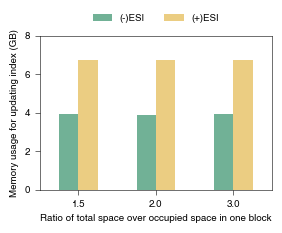

In [14]:
# charge=-1
ylim=(0,8)
save_path=path_figures / f"memory_usage_different_fold_{step}_step_options_extend_fold.svg"
plot_memory_options_fold(
    df=df,
    color_palette=color_palette,
    ylim=ylim,
    save_path=save_path
)